## Anime Recommender System: Personalized Rating Prediction using MyAnimeList Data

### 1. Introduction

This project builds a personalized anime recommender by framing recommendation as a **supervised regression** problem on MyAnimeList interaction data from Kaggle (`azathoth42/myanimelist`).

The core idea is simple:
- Input: a user-anime interaction, enriched with user and anime metadata
- Target: the user’s explicit rating `my_score` on a 1-10 scale
- Goal: predict ratings for unseen anime and rank candidates by predicted score

### Project Motivation

Traditional popularity-based recommendations ignore individual taste. This work focuses on **personalized prediction**, where each user can receive a different ranking for the same anime catalog.

### Objectives

This notebook covers data understanding and preprocessing as the foundation for downstream models:
- dataset loading and schema validation
- exploratory data analysis and sparsity profiling
- missing-value, timestamp, and data-quality checks
- leakage-aware feature preparation
- chronological train/validation/test split generation

### Modeling Roadmap

The full project compares progressively stronger approaches:
- Baseline Linear Regression for interpretability
- Tree-based model for nonlinearity # This still could be changed
- Hybrid Neural Network with user/item embeddings and dense layers

### Expected Outcome
By the end of the pipeline, we produce a clean and modeling-ready dataset that supports robust, leakage-safe evaluation and enables fair comparison across classical and deep-learning recommenders.

### 2. Machine Learning Task Description (for rubric 6 pts)

#### Supervised task definition

- **Primary task (recommended)**: **Regression**
  - Predict **`my_score`** (integer 1–10) for a given (user, anime) pair.
  - Evaluation examples: RMSE / MAE on a held-out set of rated interactions.

- **Optional variant**: **Binary classification**
  - Define a “positive” preference label, e.g. **liked = 1 if `my_score` ≥ 8** (or ≥ 7), else 0.
  - Evaluation examples: AUC, precision/recall, calibration; ranking metrics can still be computed by sorting by predicted probability.

#### Why recommendation can be framed as supervised learning

Recommendation often looks like “predict what a user will like.” With explicit user ratings available, we can treat each observed interaction as a labeled training example:

- **Inputs**: user identity + item identity (+ side features)
- **Label**: the rating the user gave

At inference time, we generate recommendations by **predicting labels for unseen items** and ranking by the predicted value.

#### Why this dataset is suitable

- **Explicit ratings as labels**: `my_score` provides direct supervision.
- **Large-scale interaction data**: many users and many anime → realistic sparsity and generalization challenges.
- **Rich anime metadata**: enables **hybrid recommenders** (collaborative + content features) and supports better cold-start behavior.


### 3. Dataset Source and Overview

- **Source**: Kaggle dataset by `azathoth42` — [MyAnimeList](https://www.kaggle.com/datasets/azathoth42/myanimelist) (scraped from MyAnimeList.net).

#### Main files (typical sizes)

- **`AnimeList.csv`**: ~14k–17k anime (anime-level metadata)
- **`UserAnimeList.csv`**: ~80M user–anime interactions (watch status + rating + timestamps)
- **`UserList.csv`**: ~300k users (user-level aggregates / profile-like stats)

#### High-level stats to compute during EDA (later)

When you load the data in later sections, you’ll report:

- **# users**: unique users in `UserAnimeList.csv`
- **# anime**: unique anime IDs in `UserAnimeList.csv` (and how many appear in `AnimeList.csv`)
- **# ratings**: interactions with `my_score` in {1..10}
- **Sparsity**: fraction of the full user–item matrix that is observed
  - If there are \(U\) users, \(I\) items, and \(R\) rated interactions, sparsity is roughly \(1 - \frac{R}{U \times I}\)
  - Expect extremely high sparsity (typical of recommender datasets)


### 4. Dataset Familiarity – Instances, Labels, Features 

#### Instances

- **Instance definition**: each row in **`UserAnimeList.csv`** corresponds to one **(user, anime)** interaction.
  - Many interactions are “watching / completed / planned” without an explicit rating.

#### Label / target

- **Target (regression)**: **`my_score`** (explicit user rating, 1–10)
- **Missing label convention**: **`my_score = 0`** typically means **not rated** (treat as missing; do not train regression on these rows)

#### Features

Features can be constructed from three levels:

- **User features**
  - **User ID**: `username` (or numeric user id if present)
  - Optional aggregates from `UserList.csv` (examples): mean score, days watched, completed count, etc.

- **Item (anime) features** from `AnimeList.csv`
  - **Genres** (multi-label)
  - **Type** (TV / Movie / OVA / Special / etc.)
  - **Source** (Manga / Light novel / Original / Game / etc.)
  - **Episodes, duration**
  - **Aired / start year**
  - **Rank, members, favorites, popularity**
  - **Community score** (note: may leak global popularity signals; use carefully)

- **Interaction features** from `UserAnimeList.csv`
  - `my_status` (watching/completed/on-hold/dropped/plan-to-watch)
  - `my_last_updated` (timestamp; useful for recency features or temporal splits)

#### Key columns cheat-sheet (starter table)

The exact column names can vary slightly across versions of the dataset; the table below captures the most common fields you’ll see and how to use them.

| File | Column (typical) | Type | Role | Purpose / Notes | Known issues / cautions |
|---|---|---:|---|---|---|
| `UserAnimeList.csv` | `username` | categorical | feature (user id) | User identifier for collaborative signals | High cardinality; treat as ID, not text |
| `UserAnimeList.csv` | `anime_id` (or `anime_id`/`anime_id_x`) | integer | feature (item id) | Anime identifier (join key into `AnimeList.csv`) | Ensure consistent dtype; watch for join mismatches |
| `UserAnimeList.csv` | `my_score` | integer | **target** | Explicit user rating 1–10 | `0` usually means **missing/not-rated**; strong label sparsity |
| `UserAnimeList.csv` | `my_status` | categorical | feature | Watch status (completed/watching/etc.) | May correlate with rating; define whether to use at prediction time |
| `UserAnimeList.csv` | `my_last_updated` | datetime/int | feature/metadata | Recency features; enables temporal split | Parse carefully; time zones/units may be inconsistent |
| `AnimeList.csv` | `anime_id` | integer | metadata (join key) | Join key to item features | Duplicates rare but possible; enforce uniqueness |
| `AnimeList.csv` | `type` | categorical | feature | Format: TV/Movie/OVA/etc. | Missing values possible |
| `AnimeList.csv` | `genres` | multi-label text | feature | Content signal for hybrid models | Needs parsing (split/one-hot/embeddings); missing/empty entries |
| `AnimeList.csv` | `source` | categorical | feature | Manga/LN/Original/etc. | Missing values possible |
| `AnimeList.csv` | `episodes` | numeric | feature | Episode count | Can be unknown/0; handle missing/outliers |
| `AnimeList.csv` | `duration` | numeric/text | feature | Episode duration | Often messy (strings); requires cleaning |
| `AnimeList.csv` | `aired` / `start_date` / `start_year` | date/year | feature | Recency/era effects; supports recency bias | Parsing inconsistencies; partial dates |
| `AnimeList.csv` | `rank` | numeric | feature/metadata | Popularity-quality proxy | Potential leakage of community preference; decide if allowed |
| `AnimeList.csv` | `members` / `popularity` | numeric | feature/metadata | Exposure/popularity features | Strong confounding with visibility |
| `AnimeList.csv` | `score` | numeric | feature/metadata | Community rating | Can leak aggregate outcomes; use carefully depending on rubric |
| `UserList.csv` | `username` | categorical | metadata (join key) | Join key to user aggregates | Not always complete for all users |
| `UserList.csv` | `mean_score` | numeric | feature | User’s average rating behavior | Derived from user history; may leak if computed on full data (recompute on train split) |
| `UserList.csv` | `days_watched` / counts | numeric | feature | User activity level | Missing values possible; often heavy-tailed |


In [1]:
# Optional (if your environment doesn't have it):
# !pip install scikit-surprise

import os
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42

random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)

# Optional dependencies (used in later sections). We import safely so EDA can run even if
# you haven't installed them yet.
try:
    from surprise import Dataset, Reader, SVD  # type: ignore

    SURPRISE_AVAILABLE = True
except Exception as e:
    SURPRISE_AVAILABLE = False
    print("[setup] 'scikit-surprise' not available yet:", repr(e))

try:
    import torch

    TORCH_AVAILABLE = True
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except Exception as e:
    TORCH_AVAILABLE = False
    print("[setup] 'torch' not available yet:", repr(e))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


### 5. Exploratory Data Analysis and Preprocessing

This section builds **dataset familiarity at an “excellent” rubric level** by:

- Characterizing **label distributions** and **interaction sparsity**
- Understanding **long-tail behavior** (ratings per user/item)
- Inspecting **anime metadata** (genres, type, release years, popularity signals)
- Handling **missing values**, **outliers**, and **messy fields** (e.g., duration)
- Preparing a **clean interaction table** that is ready for downstream modeling and evaluation

> Important practicality note: `UserAnimeList.csv` can be extremely large (~80M rows). The code below supports **full loading** when feasible, or a **chunked sample** for EDA to keep memory usage reasonable. For final model training, you can revisit loading strategy (e.g., chunked preprocessing, parquet, or a database).


#### 3.1 Data Loading

We load the three main CSVs:

- **`AnimeList.csv`**: item metadata
- **`UserAnimeList.csv`**: interactions + labels (`my_score`)
- **`UserList.csv`** (optional): user-level aggregates

We also:

- Set `low_memory=False` to reduce mixed-type inference issues.
- Specify `usecols` + `dtype` for the **largest** table to reduce memory footprint.
- Optionally **sample** `UserAnimeList.csv` for EDA.


In [2]:
%matplotlib inline

from pathlib import Path

# By default, point to the folder that contains this notebook + CSVs in this project.
# If you moved the data elsewhere, update DATA_DIR.
DATA_DIR = Path("./datasets")

PATHS = {
    "anime": DATA_DIR / "AnimeList.csv",
    "user_anime": DATA_DIR / "UserAnimeList.csv",
    "users": DATA_DIR / "UserList.csv",  # optional
}

for k, p in PATHS.items():
    print(f"{k:>10}: {p}  exists={p.exists()}")

     anime: datasets/AnimeList.csv  exists=True
user_anime: datasets/UserAnimeList.csv  exists=True
     users: datasets/UserList.csv  exists=True


In [58]:
# Loading helpers (memory-aware)

from typing import Optional


def read_csv_safely(path: Path, *, usecols=None, dtype=None, nrows=None):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}. Update DATA_DIR above.")
    return pd.read_csv(path, low_memory=False, usecols=usecols, dtype=dtype, nrows=nrows)


def load_user_anime_for_eda(
    path: Path,
    *,
    desired_cols,
    dtype,
    sample_frac: float = 0.02,
    chunksize: int = 1_000_000,
    max_rows: Optional[int] = 5_000_000,
    random_state: int = SEED,
):
    """Chunk-sample the massive interactions file for EDA.

    - Keeps memory bounded.
    - Produces a roughly random sample if the file is not ordered adversarially.
    - If you have enough RAM, set sample_frac=1.0 to load all rows (still chunked).

    The dataset schema can vary slightly; we intersect `desired_cols` with the file header.
    """

    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}. Update DATA_DIR above.")

    if not (0 < sample_frac <= 1.0):
        raise ValueError("sample_frac must be in (0, 1].")

    # Make column selection robust to minor schema differences
    header_cols = pd.read_csv(path, nrows=0).columns.tolist()
    usecols = [c for c in desired_cols if c in header_cols]

    required = {"username", "anime_id", "my_score"}
    if not required.issubset(set(usecols)):
        raise ValueError(
            "UserAnimeList.csv is missing required columns. "
            f"Required={sorted(required)}; found header sample={header_cols[:30]}"
        )

    rng = np.random.default_rng(random_state)
    out = []
    total_kept = 0
 
    for chunk in pd.read_csv(path, low_memory=False, usecols=usecols, dtype=dtype, chunksize=chunksize):
        if sample_frac < 1.0:
            chunk = chunk.sample(frac=sample_frac, random_state=int(rng.integers(0, 2**31 - 1)))

        out.append(chunk)
        total_kept += len(chunk)

        if max_rows is not None and total_kept >= max_rows:
            break

    df = pd.concat(out, ignore_index=True)

    if max_rows is not None and len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=random_state).reset_index(drop=True)

    return df


# 1) Anime metadata (small enough to load fully)
anime = read_csv_safely(PATHS["anime"])

# 2) Interactions (very large → EDA sample by default)
ua_desired_cols = ["username", "anime_id", "my_score", "my_status", "my_last_updated"]
ua_dtype = {
    "username": "string",
    "anime_id": "int32",
    "my_score": "int16",
    # Keep these as strings/ints if they exist; loader will skip them if missing.
    "my_status": "string",
    "my_last_updated": "int64",
}

user_anime = load_user_anime_for_eda(
    PATHS["user_anime"],
    desired_cols=ua_desired_cols,
    dtype=ua_dtype,
    sample_frac=0.02,      # TODO: increase if you want more precision
    max_rows=5_000_000,    # TODO: increase/decrease based on RAM
)

# 3) Optional user aggregates
users = None
if PATHS["users"].exists():
    users = read_csv_safely(PATHS["users"])

print("Loaded:")
print("- anime:", anime.shape)
print("- user_anime (EDA sample):", user_anime.shape)
print("- users:", None if users is None else users.shape)


Loaded:
- anime: (14478, 31)
- user_anime (EDA sample): (1601522, 5)
- users: (302675, 17)


In [59]:
# Integrity checks: anime_id overlap + duplicate interactions

# Guard against running cells out of order.
for name in ["anime", "user_anime"]:
    if name not in globals():
        raise RuntimeError(f"`{name}` is not defined. Run the '3.1 Data Loading' cells first.")

# 1) anime_id overlap (how many interactions have item metadata?)
anime_ids = set(pd.to_numeric(anime["anime_id"], errors="coerce").dropna().astype(int).tolist()) if "anime_id" in anime.columns else set()
ua_ids = set(pd.to_numeric(user_anime["anime_id"], errors="coerce").dropna().astype(int).tolist())

if not anime_ids:
    print("[integrity] `anime` has no `anime_id` column; cannot check overlap.")
else:
    overlap = len(ua_ids & anime_ids)
    only_in_ua = len(ua_ids - anime_ids)
    only_in_anime = len(anime_ids - ua_ids)

    print("[integrity] unique anime_ids:")
    print("- in user_anime:", len(ua_ids))
    print("- in anime metadata:", len(anime_ids))
    print("- overlap:", overlap, f"({overlap / max(1, len(ua_ids)):.2%} of interaction item-ids)")
    print("- interaction anime_ids missing from metadata:", only_in_ua)
    print("- metadata anime_ids never seen in interactions sample:", only_in_anime)

# 2) Duplicate (username, anime_id) rows
pair_cols = [c for c in ["username", "anime_id"] if c in user_anime.columns]
if len(pair_cols) == 2:
    dup_rows = int(user_anime.duplicated(pair_cols).sum())
    print("[integrity] duplicate (username, anime_id) rows:", dup_rows)

    if dup_rows > 0:
        print("[integrity] de-dup rule recommendation: keep the most recent row by `my_last_updated` if available.")
else:
    print("[integrity] missing username/anime_id columns; cannot check duplicates.")


[integrity] unique anime_ids:
- in user_anime: 12839
- in anime metadata: 14478
- overlap: 12839 (100.00% of interaction item-ids)
- interaction anime_ids missing from metadata: 0
- metadata anime_ids never seen in interactions sample: 1639
[integrity] duplicate (username, anime_id) rows: 0


In [60]:
# Quick structural sanity checks

def peek_df(df: pd.DataFrame, name: str, n: int = 5):
    print(f"\n{name} — shape={df.shape}")
    display(df.head(n))
    display(df.sample(min(n, len(df)), random_state=SEED))
    print("\ninfo():")
    df.info(show_counts=True)


peek_df(anime, "AnimeList")
peek_df(user_anime, "UserAnimeList (EDA sample)")
if users is not None:
    peek_df(users, "UserList")



AnimeList — shape=(14478, 31)


,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
0,11013,Inu x Boku SS,Inu X Boku Secret Service,妖狐×僕SS,Youko x Boku SS,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,12,Finished Airing,...,Inu x Boku SS was licensed by Sentai Filmworks...,Winter 2012,Fridays at Unknown,"{'Adaptation': [{'mal_id': 17207, 'type': 'man...","Aniplex, Square Enix, Mainichi Broadcasting Sy...",Sentai Filmworks,David Production,"Comedy, Supernatural, Romance, Shounen","['""Nirvana"" by MUCC']","['#1: ""Nirvana"" by MUCC (eps 1, 11-12)', '#2: ..."
1,2104,Seto no Hanayome,My Bride is a Mermaid,瀬戸の花嫁,The Inland Sea Bride,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,26,Finished Airing,...,NaN,Spring 2007,Unknown,"{'Adaptation': [{'mal_id': 759, 'type': 'manga...","TV Tokyo, AIC, Square Enix, Sotsu",Funimation,Gonzo,"Comedy, Parody, Romance, School, Shounen","['""Romantic summer"" by SUN&LUNAR']","['#1: ""Ashita e no Hikari (明日への光)"" by Asuka Hi..."
2,5262,Shugo Chara!! Doki,Shugo Chara!! Doki,しゅごキャラ！！どきっ,"Shugo Chara Ninenme, Shugo Chara! Second Year",https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,51,Finished Airing,...,NaN,Fall 2008,Unknown,"{'Adaptation': [{'mal_id': 101, 'type': 'manga...","TV Tokyo, Sotsu",NaN,Satelight,"Comedy, Magic, School, Shoujo","['#1: ""Minna no Tamago (みんなのたまご)"" by Shugo Cha...","['#1: ""Rottara Rottara (ロッタラ ロッタラ)"" by Buono! ..."
3,721,Princess Tutu,Princess Tutu,プリンセスチュチュ,NaN,https://myanimelist.cdn-dena.com/images/anime/...,TV,Original,38,Finished Airing,...,Princess Tutu aired in two parts. The first pa...,Summer 2002,Fridays at Unknown,"{'Adaptation': [{'mal_id': 1581, 'type': 'mang...","Memory-Tech, GANSIS, Marvelous AQL",ADV Films,Hal Film Maker,"Comedy, Drama, Magic, Romance, Fantasy","['""Morning Grace"" by Ritsuko Okazaki']","['""Watashi No Ai Wa Chiisaikeredo"" by Ritsuko ..."
4,12365,Bakuman. 3rd Season,Bakuman.,バクマン。,Bakuman Season 3,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,25,Finished Airing,...,NaN,Fall 2012,Unknown,"{'Adaptation': [{'mal_id': 9711, 'type': 'mang...","NHK, Shueisha",NaN,J.C.Staff,"Comedy, Drama, Romance, Shounen","['#1: ""Moshimo no Hanashi (もしもの話)"" by nano.RIP...","['#1: ""Pride on Everyday"" by Sphere (eps 1-13)..."


,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
12334,12133,Sekaikei Sekai Ron,NaN,セカイ系セカイ論,"World System, World Greatness",https://myanimelist.cdn-dena.com/images/anime/...,OVA,Unknown,1,Finished Airing,...,NaN,NaN,NaN,[],NaN,Sentai Filmworks,NaN,"Sci-Fi, Psychological",[],[]
8366,8619,Ladies versus Butlers! Tokuten Disc Music Clip,NaN,れでぃ×ばと!,"Ladies vs. Butlers!, Redei x Bato",https://myanimelist.cdn-dena.com/images/anime/...,Special,Light novel,1,Finished Airing,...,NaN,NaN,NaN,"{'Other': [{'mal_id': 7148, 'type': 'anime', '...",NaN,NaN,Xebec,"Ecchi, Music",[],[]
1795,18967,Zukkoke Sannin-gumi: Zukkoke Jikuu Bouken,NaN,ズッコケ三人組 ズッコケ時空冒険,NaN,https://myanimelist.cdn-dena.com/images/anime/...,OVA,Unknown,1,Finished Airing,...,NaN,NaN,NaN,"{'Alternative version': [{'mal_id': 11497, 'ty...","Nippon Columbia, Tama Production",NaN,NaN,"Comedy, Historical, Sci-Fi",[],[]
7100,36121,Ikkyuu Nyuukon,Only My Oppai Soul,一求乳魂,NaN,https://myanimelist.cdn-dena.com/images/anime/...,OVA,Manga,3,Finished Airing,...,NaN,NaN,NaN,"{'Adaptation': [{'mal_id': 105845, 'type': 'ma...",Queen Bee,NaN,NaN,"Harem, Hentai",[],[]
6050,8157,Gegege no Kitarou: Youkai Tokkyuu! Maboroshi n...,NaN,ゲゲゲの鬼太郎 妖怪特急！まぼろしの汽車,Gegege no Kitarou: Yokai Express! The Phantom ...,https://myanimelist.cdn-dena.com/images/anime/...,Movie,Unknown,1,Finished Airing,...,NaN,NaN,NaN,"{'Parent story': [{'mal_id': 7619, 'type': 'an...",NaN,NaN,Toei Animation,"Adventure, Comedy, Fantasy, Horror, Supernatural",[],[]



info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14478 entries, 0 to 14477
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   anime_id        14478 non-null  int64  
 1   title           14478 non-null  object 
 2   title_english   5724 non-null   object 
 3   title_japanese  14443 non-null  object 
 4   title_synonyms  8937 non-null   object 
 5   image_url       14382 non-null  object 
 6   type            14478 non-null  object 
 7   source          14478 non-null  object 
 8   episodes        14478 non-null  int64  
 9   status          14478 non-null  object 
 10  airing          14478 non-null  bool   
 11  aired_string    14478 non-null  object 
 12  aired           14478 non-null  object 
 13  duration        14478 non-null  object 
 14  rating          13934 non-null  object 
 15  score           14478 non-null  float64
 16  scored_by       14478 non-null  int64  
 17  rank            12904 

,username,anime_id,my_score,my_status,my_last_updated
0,Blareot,26,7,2,1411933197
1,waterdog,14807,0,6,1384262149
2,-Shimizu-,1735,8,3,1359425517
3,soccerscot15,704,6,2,1246424136
4,Kaga_Kouko,577,5,2,1399754810


,username,anime_id,my_score,my_status,my_last_updated
42059,gck99,1698,8,2,1479021826
1341851,chochajin,13053,0,2,1502015847
1136151,Nacedico,10842,9,2,1489388668
1412389,Kami-nee-sama,9925,7,2,1349848266
627743,Lacks_Sympathy,164,9,2,1247456546



info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601522 entries, 0 to 1601521
Data columns (total 5 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   username         1601517 non-null  string
 1   anime_id         1601522 non-null  int32 
 2   my_score         1601522 non-null  int16 
 3   my_status        1601522 non-null  string
 4   my_last_updated  1601522 non-null  int64 
dtypes: int16(1), int32(1), int64(1), string(2)
memory usage: 45.8 MB

UserList — shape=(302675, 17)


,username,user_id,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,access_rank,join_date,last_online,stats_mean_score,stats_rewatched,stats_episodes
0,karthiga,2255153,3,49,1,0,0,55.31,Female,"Chennai, India",1990-04-29,NaN,2013-03-03,2014-02-04 01:32:00,7.43,0.0,3391.0
1,RedvelvetDaisuki,1897606,61,396,39,0,206,118.07,Female,Manila,1995-01-01,NaN,2012-12-13,1900-05-13 02:47:00,6.78,80.0,7094.0
2,Damonashu,37326,45,195,27,25,59,83.70,Male,"Detroit,Michigan",1991-08-01,NaN,2008-02-13,1900-03-24 12:48:00,6.15,6.0,4936.0
3,bskai,228342,25,414,2,5,11,167.16,Male,"Nayarit, Mexico",1990-12-14,NaN,2009-08-31,2014-05-12 16:35:00,8.27,1.0,10081.0
4,shuzzable,2347781,36,72,16,2,25,35.48,NaN,NaN,NaN,NaN,2013-03-25,2015-09-09 21:54:00,9.06,7.0,2154.0


,username,user_id,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,access_rank,join_date,last_online,stats_mean_score,stats_rewatched,stats_episodes
231908,Blayze,238896,33,290,0,0,85,114.14,Male,"Austin, Texas",1991-08-30,NaN,2009-09-26,2013-09-13 06:21:00,7.11,30.0,6670.0
193561,3a7er,4657114,2,21,2,2,5,21.78,Male,NaN,1996-04-14,NaN,2015-06-05,2015-07-09 12:12:00,8.00,0.0,1311.0
170571,Pelo-kun,4553907,3,81,3,0,152,39.65,Male,United Kingdom,NaN,NaN,2015-04-11,1900-01-28 14:54:00,7.93,0.0,2310.0
52986,Memento-Mori,208296,4,274,5,5,41,76.96,Male,"Toronto, Ontario",NaN,NaN,2009-07-15,2012-11-01 06:55:00,6.58,26.0,4423.0
253733,Fingerknockk,5604658,4,52,0,3,10,55.75,Male,Sweden,1998-10-31,NaN,2016-08-05,2017-12-09 08:51:00,8.42,0.0,3359.0



info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302675 entries, 0 to 302674
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   username                  302674 non-null  object 
 1   user_id                   302675 non-null  int64  
 2   user_watching             302675 non-null  int64  
 3   user_completed            302675 non-null  int64  
 4   user_onhold               302675 non-null  int64  
 5   user_dropped              302675 non-null  int64  
 6   user_plantowatch          302675 non-null  int64  
 7   user_days_spent_watching  302675 non-null  float64
 8   gender                    217800 non-null  object 
 9   location                  156773 non-null  object 
 10  birth_date                168749 non-null  object 
 11  access_rank               0 non-null       float64
 12  join_date                 302546 non-null  object 
 13  last_online               302546 no

#### 3.2 Key EDA Visualizations & Insights

This subsection answers core recommender-data questions:

- **How are ratings distributed?** (label imbalance / skew)
- **How sparse is the interaction matrix?** (long-tail users/items)
- **Which metadata fields are informative vs noisy/leaky?** (genres, type, popularity signals)
- **How much missingness is present?** (affects feature engineering + model choice)
- **Are there temporal effects?** (enables time-based splits and recency features)

> Throughout, remember that the interaction table is often **not i.i.d.**: users have personal rating scales; anime have popularity exposure effects; and “missing ratings” are not random.


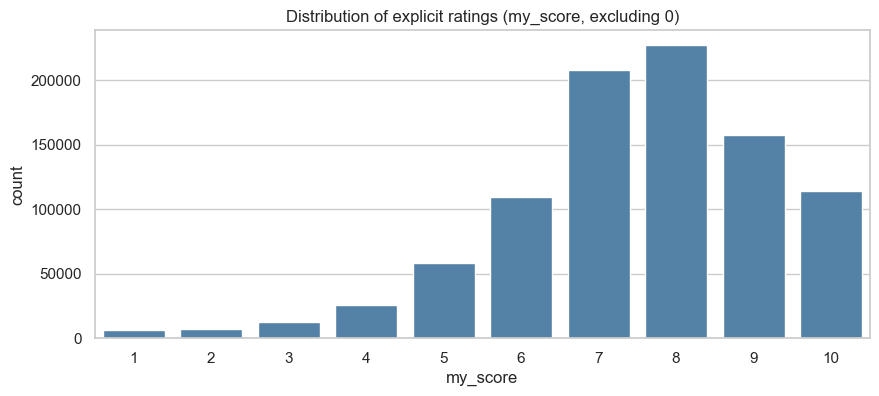

Rated interactions in EDA sample: 57.83% (my_score > 0)


In [61]:
# Rating distribution (my_score)

rated = user_anime.copy()

# my_score==0 typically means "not rated" in MAL exports
rated["is_rated"] = rated["my_score"].astype(int) > 0

plt.figure(figsize=(10, 4))
sns.countplot(
    data=rated[rated["is_rated"]],
    x="my_score",
    order=sorted(rated.loc[rated["is_rated"], "my_score"].unique()),
    color="steelblue",
)
plt.title("Distribution of explicit ratings (my_score, excluding 0)")
plt.xlabel("my_score")
plt.ylabel("count")
plt.show()

pct_rated = rated["is_rated"].mean() * 100
print(f"Rated interactions in EDA sample: {pct_rated:.2f}% (my_score > 0)")


**What to look for:**

- A common nuance in explicit-feedback datasets is **positive skew** (more 7–10 ratings than low ratings).
- This affects modeling and evaluation:
  - Predicting the mean can already look “good” under RMSE when labels cluster.
  - Error analysis should examine **user-specific bias** (some users rate harshly, others rate generously).


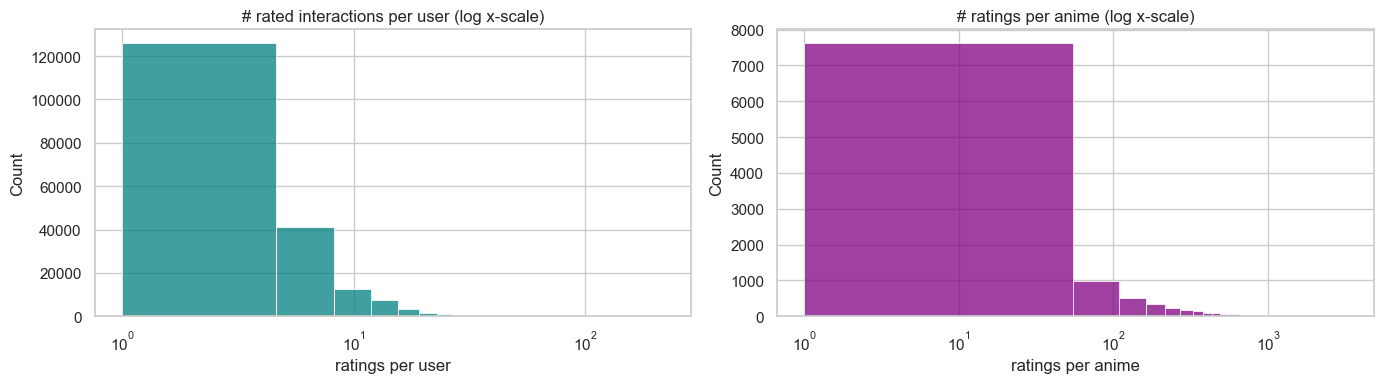

User long-tail summary:
count    194867.000000
mean          4.753032
std           5.368514
min           1.000000
50%           3.000000
80%           7.000000
90%          10.000000
95%          14.000000
99%          25.000000
max         219.000000
dtype: float64

Anime long-tail summary:
count    10590.000000
mean        87.461095
std        206.945208
min          1.000000
50%         14.000000
80%        101.000000
90%        243.000000
95%        437.550000
99%       1044.550000
max       3247.000000
dtype: float64


In [62]:
# Ratings per user and per anime (long-tail / power-law behavior)

ua_rated = rated[rated["is_rated"]].copy()

ratings_per_user = ua_rated.groupby("username", observed=True).size()
ratings_per_anime = ua_rated.groupby("anime_id", observed=True).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(ratings_per_user, bins=60, ax=axes[0], color="teal")
axes[0].set_xscale("log")
axes[0].set_title("# rated interactions per user (log x-scale)")
axes[0].set_xlabel("ratings per user")

sns.histplot(ratings_per_anime, bins=60, ax=axes[1], color="purple")
axes[1].set_xscale("log")
axes[1].set_title("# ratings per anime (log x-scale)")
axes[1].set_xlabel("ratings per anime")

plt.tight_layout()
plt.show()

print("User long-tail summary:")
print(ratings_per_user.describe(percentiles=[0.5, 0.8, 0.9, 0.95, 0.99]))
print("\nAnime long-tail summary:")
print(ratings_per_anime.describe(percentiles=[0.5, 0.8, 0.9, 0.95, 0.99]))


**Why this matters:**

- Recommender data is typically **long-tailed**: a few users rate lots of anime, and a few anime receive most ratings.
- This drives common modeling challenges:
  - **Cold-start**: users/items with very few ratings are hard to predict well.
  - **Popularity bias**: highly-rated predictions may correlate with item exposure (members/popularity).
  - **Evaluation leakage risk**: if you split randomly by rows, you may overestimate performance for heavy users; consider user-stratified or time-based splits later.


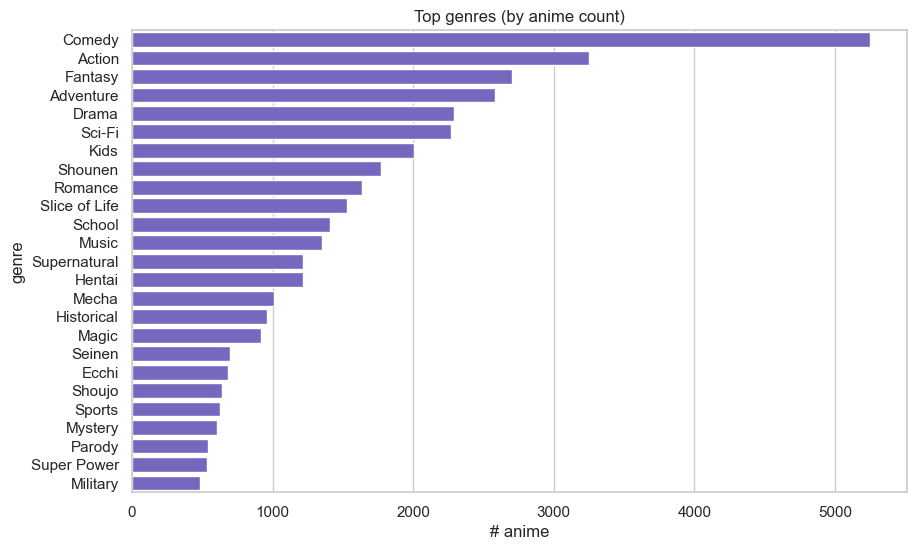

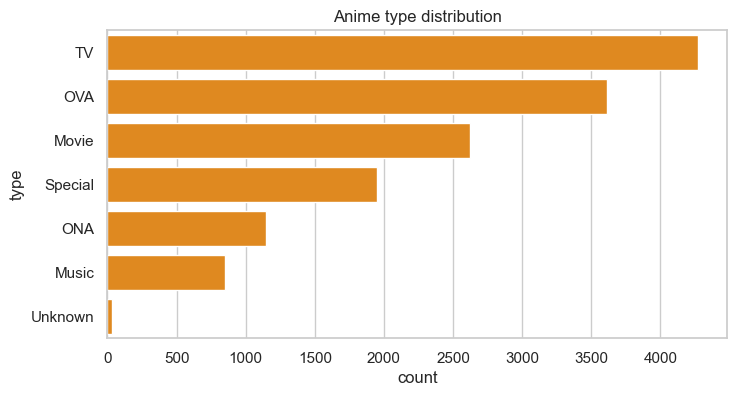

C:\Users\escan\AppData\Local\Temp\ipykernel_24172\626088666.py:51: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt = pd.to_datetime(anime[date_col], errors="coerce", infer_datetime_format=True)
C:\Users\escan\AppData\Local\Temp\ipykernel_24172\626088666.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(anime[date_col], errors="coerce", infer_datetime_format=True)


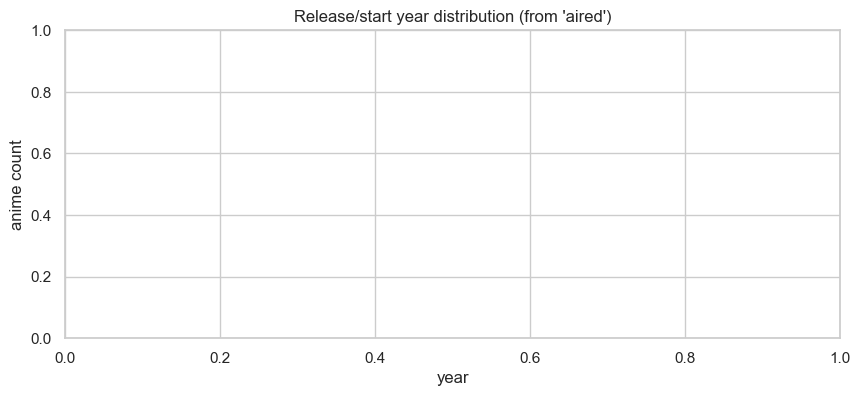

Year parsing coverage:
0.0 fraction non-missing


In [63]:
# Anime metadata: genres frequency, type distribution, release year distribution

anime_cols = set(anime.columns)

# --- Genres frequency ---
genres_col = None
for c in ["genres", "genre"]:
    if c in anime_cols:
        genres_col = c
        break

if genres_col is not None:
    genres = (
        anime[[genres_col]]
        .dropna()
        .assign(_genre=lambda d: d[genres_col].astype(str).str.split(","))
        .explode("_genre")
    )
    genres["_genre"] = genres["_genre"].astype(str).str.strip()
    genre_counts = genres[genres["_genre"].ne("")]["_genre"].value_counts().head(25)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=genre_counts.values, y=genre_counts.index, color="slateblue")
    plt.title("Top genres (by anime count)")
    plt.xlabel("# anime")
    plt.ylabel("genre")
    plt.show()
else:
    print("No genres column found (expected 'genres' or 'genre').")


# --- Type distribution ---
type_col = "type" if "type" in anime_cols else None
if type_col is not None:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=anime, y=type_col, order=anime[type_col].value_counts().index, color="darkorange")
    plt.title("Anime type distribution")
    plt.xlabel("count")
    plt.ylabel("type")
    plt.show()
else:
    print("No 'type' column found.")


# --- Release year distribution ---
# Try common date columns; fall back gracefully.
date_candidates = ["start_date", "aired", "aired_from", "premiered", "release_date"]
date_col = next((c for c in date_candidates if c in anime_cols), None)

if date_col is not None:
    dt = pd.to_datetime(anime[date_col], errors="coerce", infer_datetime_format=True)
    start_year = dt.dt.year

    plt.figure(figsize=(10, 4))
    sns.histplot(start_year.dropna(), bins=40, color="seagreen")
    plt.title(f"Release/start year distribution (from '{date_col}')")
    plt.xlabel("year")
    plt.ylabel("anime count")
    plt.show()

    print("Year parsing coverage:")
    print(start_year.notna().mean().round(3), "fraction non-missing")
else:
    print("No recognized date column found for release year.")


**Interpretation notes:**

- **Genres** are often multi-label and noisy (comma-separated strings). They’re a strong **content signal** for hybrid models, but require careful preprocessing.
- **Type** distributions (often TV-heavy) reflect platform catalog composition; modeling may benefit from type-specific biases.
- **Release year** helps capture **era effects** and can support the optional **recency bias** in ranking.


,missing_frac,missing_pct
background,0.926993,92.70
licensor,0.767026,76.70
premiered,0.717088,71.71
broadcast,0.705001,70.50
title_english,0.604642,60.46
producer,0.427545,42.75
studio,0.409863,40.99
title_synonyms,0.382719,38.27
rank,0.108717,10.87
rating,0.037574,3.76


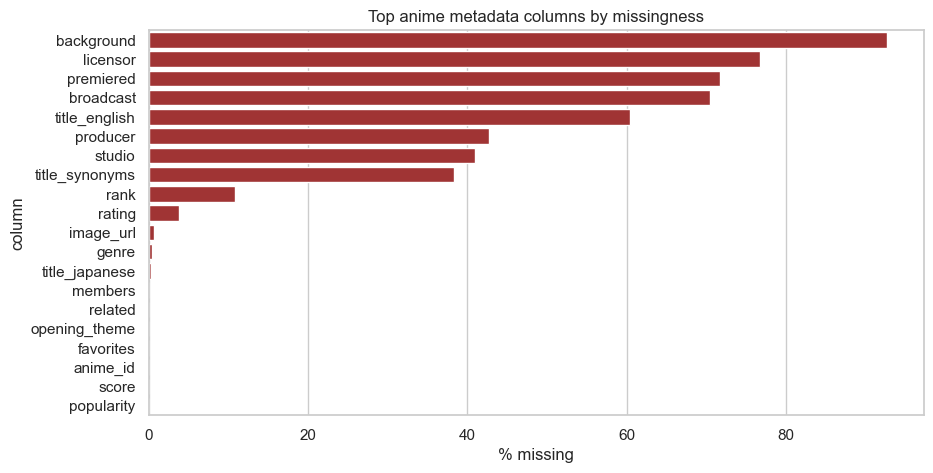

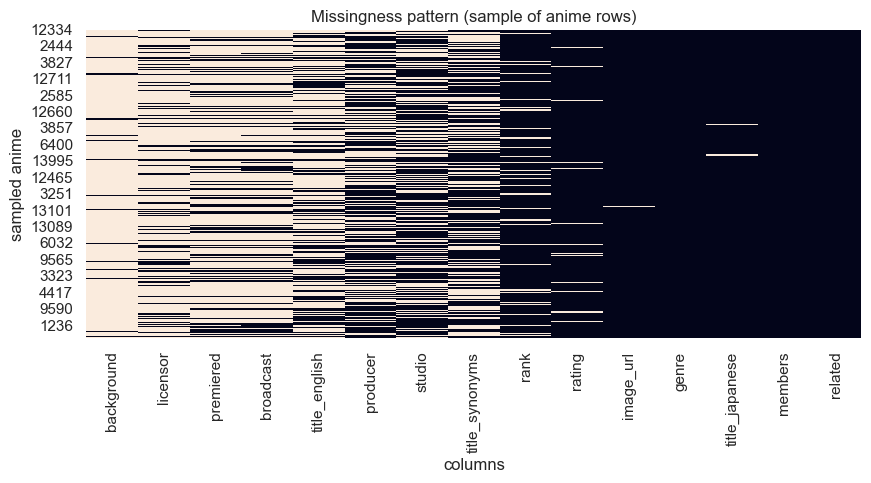

In [64]:
# Missing values summary + (small) heatmap for anime metadata

missing = (
    anime.isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_frac")
)
missing["missing_pct"] = (missing["missing_frac"] * 100).round(2)

# Show the worst offenders
display(missing.head(25))

# Plot missingness for the top columns
plt.figure(figsize=(10, 5))
sns.barplot(x=missing.head(20)["missing_pct"], y=missing.head(20).index, color="firebrick")
plt.title("Top anime metadata columns by missingness")
plt.xlabel("% missing")
plt.ylabel("column")
plt.show()

# Heatmap (limit to a small subset to keep it readable)
cols_for_heatmap = missing.head(15).index.tolist()
heat_sample = anime[cols_for_heatmap].sample(min(300, len(anime)), random_state=SEED)

plt.figure(figsize=(10, 4))
sns.heatmap(heat_sample.isna(), cbar=False)
plt.title("Missingness pattern (sample of anime rows)")
plt.xlabel("columns")
plt.ylabel("sampled anime")
plt.show()


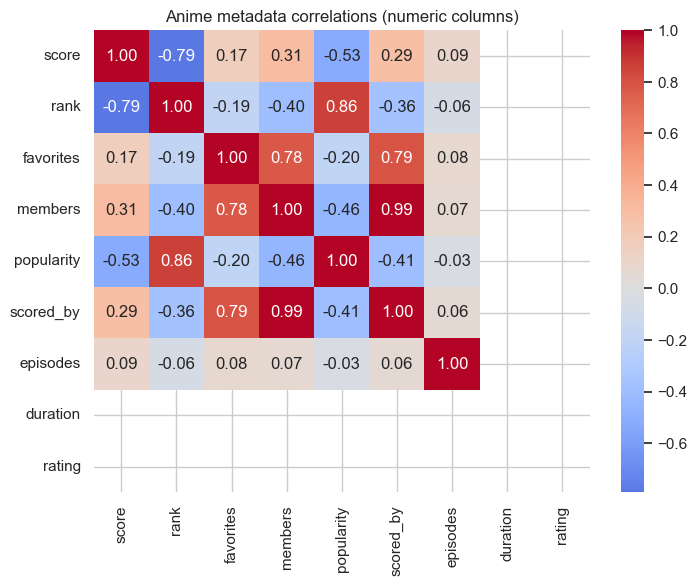

In [65]:
# Correlation matrix among common numeric anime signals
# (helps detect redundancy + potential leakage via global popularity/community scores)

numeric_candidates = [
    "score", "rank", "favorites", "members", "popularity", "scored_by",
    "episodes", "duration", "rating",
]
num_cols = [c for c in numeric_candidates if c in anime.columns]

if len(num_cols) >= 2:
    df_num = anime[num_cols].copy()

    # Coerce to numeric where possible
    for c in df_num.columns:
        df_num[c] = pd.to_numeric(df_num[c], errors="coerce")

    corr = df_num.corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Anime metadata correlations (numeric columns)")
    plt.show()
else:
    print("Not enough numeric columns found for a correlation matrix.")


**Nuance (important for rubric + modeling): leakage and confounding**

- Columns like **community `score`**, **`rank`**, **`members`**, and **`popularity`** are useful signals, but they also encode **global crowd preferences** and **exposure**.
- Depending on course rules, these features can be:
  - **Allowed but carefully justified** (they help cold-start items)
  - Or treated as **potential leakage / shortcut features** that can inflate performance without truly learning personalization.

A strong report calls this out explicitly and tests models both **with** and **without** these global signals.


Parsed last_updated_dt coverage: 1.000


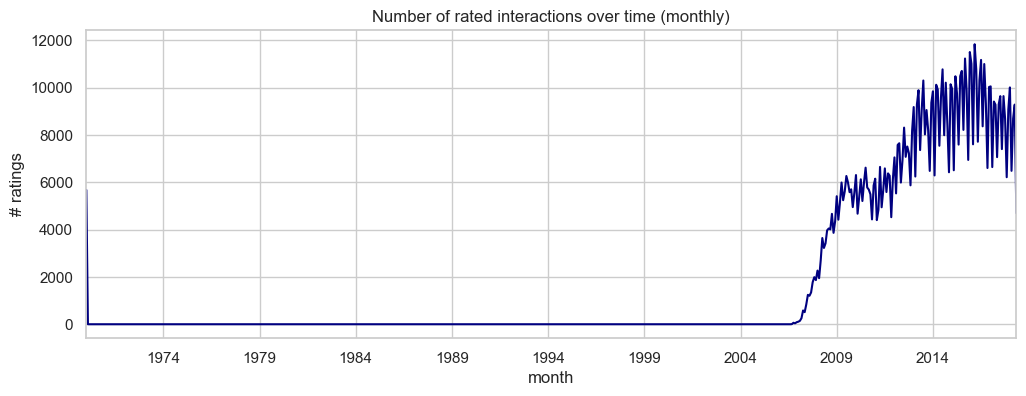

In [66]:
# Temporal dynamics: ratings over time (from my_last_updated)

ua_tmp = ua_rated.copy()

if "my_last_updated" not in ua_tmp.columns:
    print("No 'my_last_updated' column available in the loaded interactions sample.")
else:
    # my_last_updated often appears as a Unix timestamp (seconds). If your file uses ms, change unit to 'ms'.
    ua_tmp["last_updated_dt"] = pd.to_datetime(ua_tmp["my_last_updated"], unit="s", errors="coerce")

    # If parsing fails badly, try milliseconds.
    if ua_tmp["last_updated_dt"].notna().mean() < 0.2:
        ua_tmp["last_updated_dt"] = pd.to_datetime(ua_tmp["my_last_updated"], unit="ms", errors="coerce")

    coverage = ua_tmp["last_updated_dt"].notna().mean()
    print(f"Parsed last_updated_dt coverage: {coverage:.3f}")

    if coverage > 0.2:
        # Count ratings per month
        per_month = (
            ua_tmp.dropna(subset=["last_updated_dt"])
            .set_index("last_updated_dt")
            .resample("MS")
            .size()
        )

        plt.figure(figsize=(12, 4))
        per_month.plot(color="navy")
        plt.title("Number of rated interactions over time (monthly)")
        plt.xlabel("month")
        plt.ylabel("# ratings")
        plt.show()
    else:
        print("Too few timestamps parsed; check units / column contents.")


#### 3.3 Preprocessing Steps (with justifications)

Below we build a cleaned interaction dataset suitable for modeling.

Key principles:

- **Train only on explicit ratings**: `my_score==0` is not a true “0/10” label.
- **Reduce extreme sparsity**: prune very low-activity users and very low-exposure items to stabilize baselines and reduce variance.
- **Standardize messy metadata**: parse duration, extract year, normalize genres.
- **Treat outliers carefully**: cap extreme values to reduce the influence of data-entry errors.
- **Prepare for time-aware evaluation**: parse and sort timestamps for future time-based splits.


In [67]:
# 1) Filter interactions: keep only explicit ratings

before_rows = len(user_anime)
ua = user_anime.copy()
ua = ua[ua["my_score"].astype(int) >= 1].copy()
after_rows = len(ua)

print(f"UserAnimeList rows (EDA sample): {before_rows:,}")
print(f"Rated rows kept (my_score>=1): {after_rows:,}  ({after_rows / before_rows:.2%})")

# Basic label sanity
ua["my_score"] = ua["my_score"].astype(int)
print("my_score value counts (top):")
print(ua["my_score"].value_counts().sort_index())


UserAnimeList rows (EDA sample): 1,601,522
Rated rows kept (my_score>=1): 926,213  (57.83%)
my_score value counts (top):
my_score
1       6517
2       7550
3      12369
4      25774
5      58145
6     109294
7     207725
8     227294
9     157562
10    113983
Name: count, dtype: int64


In [68]:
# 2) Sparsity reduction (activity / support thresholds)
# Justification: very low-support users/items create high-variance targets and unstable evaluation.

MIN_RATINGS_PER_USER = 20
MIN_RATINGS_PER_ANIME = 50

user_counts = ua.groupby("username", observed=True).size()
anime_counts = ua.groupby("anime_id", observed=True).size()

keep_users = user_counts[user_counts >= MIN_RATINGS_PER_USER].index
keep_anime = anime_counts[anime_counts >= MIN_RATINGS_PER_ANIME].index

ua_f = ua[ua["username"].isin(keep_users) & ua["anime_id"].isin(keep_anime)].copy()

print("After sparsity reduction:")
print("- users kept:", ua_f["username"].nunique())
print("- anime kept:", ua_f["anime_id"].nunique())
print("- ratings kept:", len(ua_f))


After sparsity reduction:
- users kept: 4176
- anime kept: 3121
- ratings kept: 91209


In [69]:
# 3) Clean and engineer anime metadata features

anime_clean = anime.copy()

# --- Duration parsing (to minutes) ---
# Duration fields can appear as numbers or strings like "24 min per ep".
if "duration" in anime_clean.columns:
    dur_raw = anime_clean["duration"].astype(str)
    dur_min = pd.to_numeric(dur_raw.str.extract(r"(\d+(?:\.\d+)?)")[0], errors="coerce")

    # Impute missing with median (simple, robust baseline)
    median_dur = dur_min.median(skipna=True)
    anime_clean["duration_min"] = dur_min.fillna(median_dur)
else:
    anime_clean["duration_min"] = np.nan


# --- Start year extraction ---
start_year = None
for c in ["start_date", "aired", "aired_from", "release_date"]:
    if c in anime_clean.columns:
        dt = pd.to_datetime(anime_clean[c], errors="coerce")
        start_year = dt.dt.year
        anime_clean["start_year"] = start_year
        break

if "start_year" not in anime_clean.columns:
    anime_clean["start_year"] = np.nan


# --- Genres list (keep as list; one-hot can be created later) ---
if genres_col is not None and genres_col in anime_clean.columns:
    anime_clean["genres_list"] = (
        anime_clean[genres_col]
        .fillna("")
        .astype(str)
        .apply(lambda s: [g.strip() for g in s.split(",") if g.strip()])
    )
else:
    anime_clean["genres_list"] = [[] for _ in range(len(anime_clean))]


# 4) Outlier handling (winsorize/cap extremes)
# Justification: extreme values may be data-entry errors or rare edge cases that dominate losses.

# Episodes
if "episodes" in anime_clean.columns:
    ep = pd.to_numeric(anime_clean["episodes"], errors="coerce")
    hi = ep.quantile(0.995)
    anime_clean["episodes_capped"] = ep.clip(upper=hi)

# Duration (minutes)
if "duration_min" in anime_clean.columns:
    hi = anime_clean["duration_min"].quantile(0.995)
    anime_clean["duration_min_capped"] = anime_clean["duration_min"].clip(upper=hi)


print("Anime feature columns created:")
created = [c for c in ["duration_min", "duration_min_capped", "start_year", "episodes_capped", "genres_list"] if c in anime_clean.columns]
print(created)


C:\Users\escan\AppData\Local\Temp\ipykernel_24172\3017110843.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(anime_clean[c], errors="coerce")


Anime feature columns created:
['duration_min', 'duration_min_capped', 'start_year', 'episodes_capped', 'genres_list']


In [70]:
# 5) Time-based split preparation
# Convert to datetime and sort interactions per user.

ua_f = ua_f.copy()

if "my_last_updated" in ua_f.columns:
    ua_f["last_updated_dt"] = pd.to_datetime(ua_f["my_last_updated"], unit="s", errors="coerce")

    # If parsing fails badly, try milliseconds:
    if ua_f["last_updated_dt"].notna().mean() < 0.2:
        ua_f["last_updated_dt"] = pd.to_datetime(ua_f["my_last_updated"], unit="ms", errors="coerce")

    print("Timestamp parsing coverage (after fallback):", ua_f["last_updated_dt"].notna().mean().round(3))
else:
    # Still create the column so downstream code is stable.
    ua_f["last_updated_dt"] = pd.NaT
    print("No 'my_last_updated' column available; skipping time parsing.")

ua_f = ua_f.sort_values(["username", "last_updated_dt"], kind="mergesort")


Timestamp parsing coverage (after fallback): 1.0


In [71]:
# 6) Optional: implicit feedback label
# Useful for a classification variant or for ranking metrics.

IMPLICIT_POS_THRESHOLD = 7

ua_f["implicit_positive"] = (ua_f["my_score"] >= IMPLICIT_POS_THRESHOLD).astype(int)

# Alternative / additional rule (commented): treat completed as positive signal
# ua_f["implicit_positive"] = (
#     (ua_f["my_score"] >= IMPLICIT_POS_THRESHOLD) | (ua_f["my_status"].str.lower().eq("completed"))
# ).astype(int)

ua_f[["my_score", "implicit_positive"]].head()


,my_score,implicit_positive
730690,10,1
726982,9,1
721055,8,1
733165,7,1
732338,7,1


#### 3.4 Introducing Sparcity

We summarize what changed through preprocessing:

- Shapes **before/after** filtering
- Number of **users**, **anime**, and **ratings** retained
- **Sparsity** estimate of the resulting user–item matrix

> After this point, the dataset is ready for modeling (matrix factorization, hybrid regressors, neural embedding models). We intentionally **stop here** to keep EDA/preprocessing separate from training.


In [72]:
# Before/after summary + sparsity calculation

summary = {
    "user_anime_rows_sampled": len(user_anime),
    "rated_rows": len(ua),
    "after_threshold_rows": len(ua_f),
    "n_users": ua_f["username"].nunique(),
    "n_anime": ua_f["anime_id"].nunique(),
}
summary["n_ratings"] = summary["after_threshold_rows"]

U = summary["n_users"]
I = summary["n_anime"]
R = summary["n_ratings"]

# Sparsity of the observed matrix
sparsity = 1.0 - (R / (U * I)) if U > 0 and I > 0 else np.nan

print(pd.Series(summary))
print(f"\nEstimated sparsity after filtering: {sparsity:.6f}  ({sparsity*100:.3f}% empty)")

display(ua_f.head())

# Keep the final interaction table small and modeling-friendly
cols = ["username", "anime_id", "my_score", "implicit_positive", "last_updated_dt"]
if "my_status" in ua_f.columns:
    cols.insert(4, "my_status")

final_interactions = ua_f[cols].copy()

print("\nFinal interactions table:")
final_interactions.info(show_counts=True)

user_anime_rows_sampled    1601522
rated_rows                  926213
after_threshold_rows         91209
n_users                       4176
n_anime                       3121
n_ratings                    91209
dtype: int64

Estimated sparsity after filtering: 0.993002  (99.300% empty)


,username,anime_id,my_score,my_status,my_last_updated,last_updated_dt,implicit_positive
730690,--ALEX--,2685,10,2,1214000985,2008-06-20 22:29:45,1
726982,--ALEX--,355,9,2,1216449029,2008-07-19 06:30:29,1
721055,--ALEX--,1066,8,2,1216629162,2008-07-21 08:32:42,1
733165,--ALEX--,3221,7,2,1216706724,2008-07-22 06:05:24,1
732338,--ALEX--,3712,7,2,1222314473,2008-09-25 03:47:53,1



Final interactions table:
<class 'pandas.core.frame.DataFrame'>
Index: 91209 entries, 730690 to 130743
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   username           91209 non-null  string        
 1   anime_id           91209 non-null  int32         
 2   my_score           91209 non-null  int64         
 3   implicit_positive  91209 non-null  int64         
 4   my_status          91209 non-null  string        
 5   last_updated_dt    91209 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int32(1), int64(2), string(2)
memory usage: 4.5 MB


### 6. Feature Selection

#### Features
* `episodes` : The length of a show dictates the required time investment, which can heavily influence a user's final rating due to character attachment or pacing preferences.
  
* `score` : An anime's global average rating serves as the strongest baseline predictor since critically acclaimed shows are statistically more likely to receive high individual scores.

* `popularity` : This metric measures overall mainstream visibility, helping the model identify if a user favors hyped blockbusters or obscure niche titles.

* `favorites` : A high favorite count highlights a show with a deeply passionate fanbase, which strongly correlates with users giving out perfect 10s.

* `user_watching` : The number of shows a user is currently juggling indicates their present engagement level and how their attention is divided.

* `user_completed` : The total number of finished shows measures a user's experience level, as veteran viewers generally tend to grade more critically than newcomers.

* `user_onhold` : This metric acts as an indicator of a user's attention span and their tendency to pause shows rather than committing to them.

* `user_dropped` : A high number of dropped shows is a strong signal of a harsh or impatient critic, telling the model to conservatively lower its predicted scores for that individual.

* `user_plantowatch` : A massive "plan to watch" backlog shows a user's susceptibility to seasonal hype and trends, which influences how they score highly anticipated shows.

* `user_days_spent_watching` : This ultimate measure of total time invested in the medium establishes exactly how deep into the anime ecosystem the viewer is.

In [73]:
# features to add to final_interactions

anime_cols = [
    'episodes',
    'score',
    'popularity',
    'favorites',
]

user_col = [
    'user_watching',
    'user_completed',
    'user_onhold',
    'user_dropped',
    'user_plantowatch',
    'user_days_spent_watching',
]

In [74]:
# Merge final_interactions with cleaned anime features
anime_merge = final_interactions.merge(
    anime_clean[['anime_id'] + anime_cols],
    on="anime_id",
    how="left",
    validate="m:1"
)

anime_merge.head()

,username,anime_id,my_score,implicit_positive,my_status,last_updated_dt,episodes,score,popularity,favorites
0,--ALEX--,2685,10,1,2,2008-06-20 22:29:45,3,8.40,1209,830
1,--ALEX--,355,9,1,2,2008-07-19 06:30:29,24,7.66,144,5146
2,--ALEX--,1066,8,1,2,2008-07-21 08:32:42,4,7.19,2133,37
3,--ALEX--,3221,7,1,2,2008-07-22 06:05:24,1,7.22,2609,17
4,--ALEX--,3712,7,1,2,2008-09-25 03:47:53,12,7.56,250,777


In [75]:
# Merge final_interactions with user features
final_merge = anime_merge.merge(
    users[['username'] + user_col],
    on="username",
    how="left",
    validate="m:1"
)


final_merge.head()

,username,anime_id,my_score,implicit_positive,my_status,last_updated_dt,episodes,score,popularity,favorites,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching
0,--ALEX--,2685,10,1,2,2008-06-20 22:29:45,3,8.40,1209,830,9,748,14,18,16,149.37
1,--ALEX--,355,9,1,2,2008-07-19 06:30:29,24,7.66,144,5146,9,748,14,18,16,149.37
2,--ALEX--,1066,8,1,2,2008-07-21 08:32:42,4,7.19,2133,37,9,748,14,18,16,149.37
3,--ALEX--,3221,7,1,2,2008-07-22 06:05:24,1,7.22,2609,17,9,748,14,18,16,149.37
4,--ALEX--,3712,7,1,2,2008-09-25 03:47:53,12,7.56,250,777,9,748,14,18,16,149.37


In [76]:
# Filtering pipeline before saving
work = final_merge.copy()

# Explicit ratings only
work["my_score"] = pd.to_numeric(work["my_score"], errors="coerce")
work = work[work["my_score"] >= 1].copy()

# Parse timestamp safely
work["last_updated_dt"] = pd.to_datetime(work["last_updated_dt"], errors="coerce")

# Keep only rows with valid and plausible timestamps for chronological split
before_ts = len(work)
work = work.dropna(subset=["last_updated_dt"]).copy()

min_valid_dt = pd.Timestamp("2000-01-01")
max_valid_dt = pd.Timestamp("2030-01-01")
out_of_range_mask = (work["last_updated_dt"] < min_valid_dt) | (work["last_updated_dt"] > max_valid_dt)
dropped_out_of_range = int(out_of_range_mask.sum())
work = work.loc[~out_of_range_mask].copy()

# Optional de-duplication: keep latest user-anime interaction
if {"username", "anime_id"}.issubset(work.columns):
    work = work.sort_values("last_updated_dt")
    work = work.drop_duplicates(subset=["username", "anime_id"], keep="last")

print("After rating filter + timestamp filter + dedup:")
print("Rows:", len(work))
print("Dropped invalid timestamp rows:", before_ts - len(work) - dropped_out_of_range)
print("Dropped out-of-range timestamp rows:", dropped_out_of_range)

display(work.head())

After rating filter + timestamp filter + dedup:
Rows: 90544
Dropped invalid timestamp rows: 0
Dropped out-of-range timestamp rows: 665


,username,anime_id,my_score,implicit_positive,my_status,last_updated_dt,episodes,score,popularity,favorites,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching
84194,scorpedo,195,7,1,2,2006-10-09 04:41:50,12,7.30,732,801,19,1335,0,3,54,341.62
65438,chocopocky,822,7,1,2,2006-10-14 11:53:56,2,7.45,2567,28,17,1039,9,40,32,205.59
65439,chocopocky,145,9,1,2,2006-10-15 10:19:02,26,7.64,702,1444,17,1039,9,40,32,205.59
65440,chocopocky,597,8,1,2,2006-10-15 10:22:56,1,7.94,719,640,17,1039,9,40,32,205.59
65441,chocopocky,207,5,0,2,2006-10-15 10:35:48,13,7.52,1899,366,17,1039,9,40,32,205.59


In [77]:
output_path = "./processed-data/anime.csv"
work.to_csv(output_path, index=False)
print(f"Saved filtered dataset: {output_path} | rows={len(work):,}")

Saved filtered dataset: ./processed-data/anime.csv | rows=90,544


# 5. Feature Spliting

In [78]:
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

INPUT_CANDIDATES = [
    Path("processed-data/anime.parquet"),
    Path("processed-data/anime.csv"),
]

OUT_DIR = Path("processed-data/splits")
OUT_DIR.mkdir(parents=True, exist_ok = True)

Load source dataset and validate schema.

In [79]:
src_path = None

for p in INPUT_CANDIDATES:
    if p.exists():
        src_path = p
        break

if src_path is None:
    raise FileNotFoundError("dataset is not found.")

if src_path.suffix.lower() == '.parquet':
    df = pd.read_parquet(src_path)
else:
    df = pd.read_csv(src_path, low_memory=False)

required_cols = ["username", "anime_id", "my_score", "last_updated_dt"]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Loaded:", src_path.resolve())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Loaded: C:\Users\escan\Documents\02-academics\25-26\term_2\stintsy\01-actual-folder\STINTSYMajorOutput\processed-data\anime.csv
Shape: (90544, 16)
Columns: ['username', 'anime_id', 'my_score', 'implicit_positive', 'my_status', 'last_updated_dt', 'episodes', 'score', 'popularity', 'favorites', 'user_watching', 'user_completed', 'user_onhold', 'user_dropped', 'user_plantowatch', 'user_days_spent_watching']
